In [ ]:
import pandas as pd
import numpy as np
import sklearn

# Display all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Download the data

In [6]:
beer_data = pd.read_excel("/Users/kenlam/Desktop/DST/beer_rec/Beer_data (1).xlsx")

In [7]:
beer_data.head()

,Name,Style,Brewery,Beer.Name..Full.,Description,UMAP1,UMAP2,cluster,clus_name,Style_simple,...,Fruits,Hoppy,Spices,Malty,review_aroma,review_appearance,review_palate,review_taste,review_overall,number_of_reviews
0,Amber,Altbier,Alaskan Brewing Co.,Alaskan Brewing Co. Alaskan Amber,"Notes:Richly malty and long on the palate, wit...",0.418745,-1.841660,1,Hoppy / Dry,Altbier,...,33,57,8,111,3.498994,3.636821,3.556338,3.643863,3.847082,497
1,Double Bag,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Double Bag,"Notes:This malty, full-bodied double alt is al...",-1.215652,-0.698988,3,Malty / Smooth,Altbier,...,24,35,12,84,3.798337,3.846154,3.904366,4.024948,4.034304,481
2,Long Trail Ale,Altbier,Long Trail Brewing Co.,Long Trail Brewing Co. Long Trail Ale,Notes:Long Trail Ale is a full-bodied amber al...,1.328001,-1.876289,1,Hoppy / Dry,Altbier,...,10,54,4,62,3.409814,3.667109,3.600796,3.631300,3.830239,377
3,Doppelsticke,Altbier,Uerige Oberg√§rige Hausbrauerei GmbH / Zum Uerige,Uerige Oberg√§rige Hausbrauerei GmbH / Zum Uer...,Notes:,-3.353812,0.204987,4,Sweet / Strong,Altbier,...,49,40,16,119,4.148098,4.033967,4.150815,4.205163,4.005435,368
4,Sleigh'r Dark Do√ºble Alt Ale,Altbier,Ninkasi Brewing Company,Ninkasi Brewing Company Sleigh'r Dark Do√ºble ...,Notes:Called 'Dark Double Alt' on the label.Se...,0.641762,-2.403550,1,Hoppy / Dry,Altbier,...,11,51,20,95,3.625000,3.973958,3.734375,3.765625,3.817708,96


# Split data into training data

In [19]:
# Get only the necessary columns
training_data = beer_data.iloc[:, 8:24]

training_data.head()

,clus_name,Style_simple,ABV,Min.IBU,Max.IBU,Astringency,Body,Alcohol,Bitter,Sweet,Sour,Salty,Fruits,Hoppy,Spices,Malty
0,Hoppy / Dry,Altbier,5.3,25,50,13,32,9,47,74,33,0,33,57,8,111
1,Malty / Smooth,Altbier,7.2,25,50,12,57,18,33,55,16,0,24,35,12,84
2,Hoppy / Dry,Altbier,5.0,25,50,14,37,6,42,43,11,0,10,54,4,62
3,Sweet / Strong,Altbier,8.5,25,50,13,55,31,47,101,18,1,49,40,16,119
4,Hoppy / Dry,Altbier,7.2,25,50,25,51,26,44,45,9,1,11,51,20,95


In [22]:
# See if there are any NAs
training_data.isna().sum().sum()

0

In [ ]:
# Split in X and Y
y = training_data["Style_simple"]
X = training_data.iloc[:, 2:]

len(y.unique()) # we have 43 unique beer styles

43

# Train base model (XGBoost)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def train_and_evaluate_xgboost(X, y, test_size=0.2, n_estimators=100, random_state=42):
    """
    Train an XGBoost classifier and return performance metrics.
    
    Parameters:
    -----------
    X : array-like
        Feature matrix
    y : array-like
        Target variable (can be string or numeric)
    test_size : float
        Proportion of data to use for testing (default: 0.2)
    n_estimators : int
        Number of XGBoost estimators (default: 100)
    random_state : int
        Random seed for reproducibility (default: 42)
    
    Returns:
    --------
    dict : Dictionary containing model, metrics, and label encoder
    """
    
    # Encode target variable
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=test_size, random_state=random_state
    )
    
    # Train XGBoost model
    model = XGBClassifier(n_estimators=n_estimators, random_state=random_state, verbosity=0)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Print results
    print("XGBoost Model Performance Metrics")
    print("=" * 40)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\n" + "=" * 40)
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))
    
    # Return results
    return {
        'model': model,
        'label_encoder': le,
        'metrics': {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1
        },
        'y_test': y_test,
        'y_pred': y_pred
    }

# Train and evaluate the model
results = train_and_evaluate_xgboost(X, y)

XGBoost Model Performance Metrics
Accuracy:  0.8406
Precision: 0.8425
Recall:    0.8406
F1-Score:  0.8342


Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.90      0.95      0.92        19
           2       0.87      0.72      0.79        18
           3       0.00      0.00      0.00         4
           4       0.80      0.86      0.83        14
           5       0.81      0.85      0.83        34
           6       1.00      0.20      0.33         5
           7       0.00      0.00      0.00         1
           8       1.00      0.58      0.73        26
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         9
          12       1.00      0.91      0.95        11
          13       0.73      1.00      0.85        11
          14       1.00      1.00      1.00      

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python

# PCA Analysis

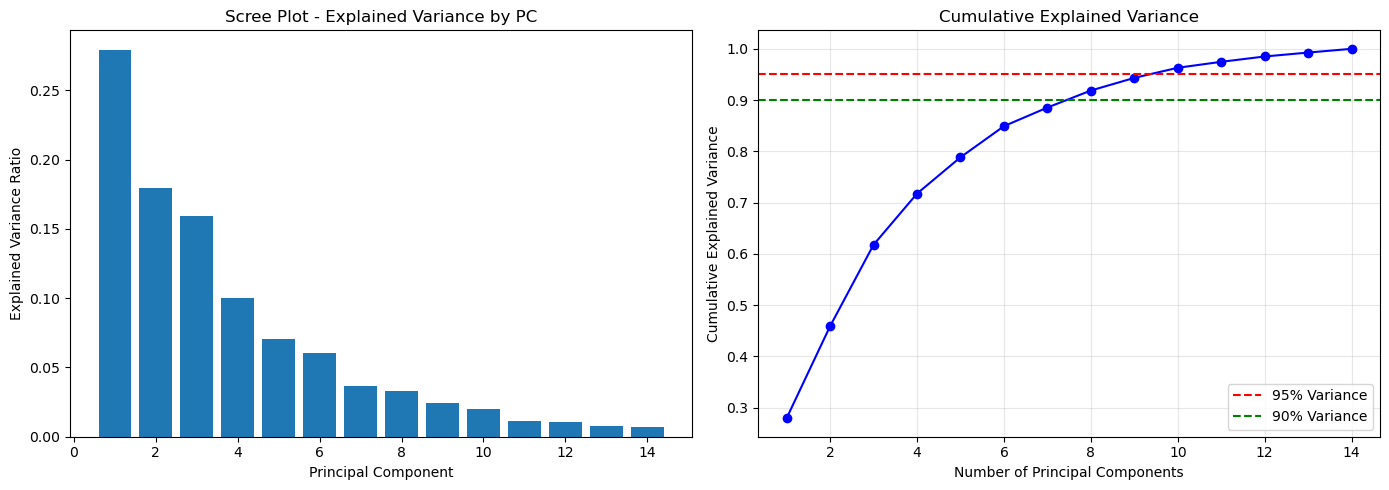


Number of components needed to explain:
  90% variance: 8
  95% variance: 10
  99% variance: 13

Total original features: 14


In [35]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the features (PCA requires standardized data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA with all components to see explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Calculate cumulative explained variance
cumsum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
            pca_full.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot - Explained Variance by PC')

# Cumulative explained variance
axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var, 'bo-')
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
axes[1].axhline(y=0.90, color='g', linestyle='--', label='90% Variance')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components for different variance thresholds
n_components_90 = np.argmax(cumsum_var >= 0.90) + 1
n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
n_components_99 = np.argmax(cumsum_var >= 0.99) + 1

print(f"\nNumber of components needed to explain:")
print(f"  90% variance: {n_components_90}")
print(f"  95% variance: {n_components_95}")
print(f"  99% variance: {n_components_99}")
print(f"\nTotal original features: {X.shape[1]}")

In [36]:
# Interpret Principal Components
# Use the number of components that explain 95% of variance

n_components = n_components_95  # or choose another threshold

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Create loadings dataframe for interpretation
loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X.columns
)

print(f"\n{'='*60}")
print(f"PCA Loadings (Feature Contributions to Each PC)")
print(f"{'='*60}\n")
print(loadings_df.round(3))

# Interpret each component
print(f"\n{'='*60}")
print(f"PC Interpretations (Top 3 contributing features)")
print(f"{'='*60}\n")

for i in range(n_components):
    pc_name = f'PC{i+1}'
    # Get absolute loadings sorted
    top_features = loadings_df[pc_name].abs().nlargest(3)
    
    print(f"{pc_name} (Explains {pca.explained_variance_ratio_[i]:.2%} of variance):")
    for feature, loading in top_features.items():
        direction = "positive" if loadings_df.loc[feature, pc_name] > 0 else "negative"
        print(f"  - {feature}: {loadings_df.loc[feature, pc_name]:.4f} ({direction})")
    print()


PCA Loadings (Feature Contributions to Each PC)

               PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8    PC9  \
ABV          0.317  0.209 -0.252 -0.223  0.132 -0.161  0.093  0.371  0.636   
Min.IBU      0.386 -0.064  0.132 -0.395  0.032 -0.020 -0.347 -0.021 -0.246   
Max.IBU      0.397 -0.007  0.066 -0.402  0.066  0.033 -0.326 -0.125 -0.211   
Astringency -0.049  0.284  0.456  0.228  0.069 -0.024 -0.114  0.596 -0.330   
Body         0.350 -0.140 -0.039  0.458 -0.059  0.063 -0.368  0.121  0.238   
Alcohol      0.305  0.194 -0.300 -0.055  0.189 -0.209  0.451  0.290 -0.366   
Bitter       0.325 -0.237  0.369  0.067 -0.064  0.184  0.135  0.040  0.286   
Sweet        0.314  0.261 -0.170  0.292 -0.245 -0.202  0.123 -0.382 -0.170   
Sour        -0.017  0.548  0.202  0.069 -0.171  0.083 -0.179  0.063  0.130   
Salty       -0.066  0.066  0.285  0.132  0.680 -0.543 -0.113 -0.300  0.144   
Fruits       0.103  0.559  0.083  0.000 -0.119  0.141  0.015 -0.356  0.102   
Hoppy        0

In [38]:
# Train XGBoost model with PCA-reduced features
print(f"\n{'='*60}")
print(f"Training XGBoost with {n_components} Principal Components")
print(f"{'='*60}\n")

results_pca = train_and_evaluate_xgboost(X_pca, y, test_size=0.2, n_estimators=100, random_state=42)

# Compare original vs PCA model
print(f"\n{'='*60}")
print(f"Model Comparison: Original Features vs PCA")
print(f"{'='*60}")
print(f"\nOriginal Features ({X.shape[1]} features):")
print(f"  Accuracy: {results['metrics']['accuracy']:.4f}")
print(f"  F1-Score: {results['metrics']['f1']:.4f}")

print(f"\nPCA Reduced ({n_components} components):")
print(f"  Accuracy: {results_pca['metrics']['accuracy']:.4f}")
print(f"  F1-Score: {results_pca['metrics']['f1']:.4f}")
print(f"  Dimensionality Reduction: {X.shape[1]} → {n_components} ({100*n_components/X.shape[1]:.1f}% of original)")


Training XGBoost with 10 Principal Components

XGBoost Model Performance Metrics
Accuracy:  0.5922
Precision: 0.5881
Recall:    0.5922
F1-Score:  0.5774


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.44      0.44         9
           1       0.83      0.79      0.81        19
           2       0.71      0.56      0.62        18
           3       0.00      0.00      0.00         4
           4       0.43      0.43      0.43        14
           5       0.39      0.38      0.39        34
           6       0.00      0.00      0.00         5
           7       0.00      0.00      0.00         1
           8       0.61      0.42      0.50        26
           9       0.33      0.67      0.44         3
          10       1.00      0.71      0.83         7
          11       0.50      0.11      0.18         9
          12       0.58      0.64      0.61        11
          13       0.29      0.18      0.22        11
 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python